In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.DataFrame({
    'Model': ['GPT-2', 'LLaMA2', 'T5', 'GPT-Neo', 'BLOOM'],
    'BLEU': [28, 35, 30, 27, 33],
    'ROUGE': [32, 40, 38, 30, 37],
    'Perplexity': [35, 18, 25, 40, 22],
    'Time': [120, 200, 150, 110, 250],
    'Size': [1.5, 7, 3, 2.7, 10]
})

print("Original Decision Matrix:\n")
print(data)

Original Decision Matrix:

     Model  BLEU  ROUGE  Perplexity  Time  Size
0    GPT-2    28     32          35   120   1.5
1   LLaMA2    35     40          18   200   7.0
2       T5    30     38          25   150   3.0
3  GPT-Neo    27     30          40   110   2.7
4    BLOOM    33     37          22   250  10.0


In [3]:
matrix = data.iloc[:, 1:].values

In [6]:
norm = matrix / np.sqrt((matrix ** 2).sum(axis=0))


In [5]:
weights = np.array([0.25, 0.25, 0.20, 0.15, 0.15])
weighted_matrix = norm * weights

print("\nWeighted Normalized Matrix:\n")
print(weighted_matrix)


Weighted Normalized Matrix:

[[0.10181347 0.10049585 0.10727418 0.04624515 0.01738294]
 [0.12726684 0.12561981 0.05516958 0.07707525 0.08112039]
 [0.10908586 0.11933882 0.07662442 0.05780644 0.03476588]
 [0.09817727 0.09421486 0.12259907 0.04239139 0.03128929]
 [0.11999445 0.11619833 0.06742949 0.09634406 0.11588628]]


In [7]:
ideal_best = np.array([
    max(weighted_matrix[:,0]),   # BLEU max
    max(weighted_matrix[:,1]),   # ROUGE max
    min(weighted_matrix[:,2]),   # Perplexity min
    min(weighted_matrix[:,3]),   # Time min
    min(weighted_matrix[:,4])    # Size min
])

ideal_worst = np.array([
    min(weighted_matrix[:,0]),
    min(weighted_matrix[:,1]),
    max(weighted_matrix[:,2]),
    max(weighted_matrix[:,3]),
    max(weighted_matrix[:,4])
])

print("\nIdeal Best:\n", ideal_best)
print("\nIdeal Worst:\n", ideal_worst)


Ideal Best:
 [0.12726684 0.12561981 0.05516958 0.04239139 0.01738294]

Ideal Worst:
 [0.09817727 0.09421486 0.12259907 0.09634406 0.11588628]


In [8]:
dist_best = np.sqrt(((weighted_matrix - ideal_best) ** 2).sum(axis=1))
dist_worst = np.sqrt(((weighted_matrix - ideal_worst) ** 2).sum(axis=1))

print("\nDistance from Ideal Best:\n", dist_best)
print("\nDistance from Ideal Worst:\n", dist_worst)


Distance from Ideal Best:
 [0.06331531 0.0725633  0.03701485 0.08107155 0.1136035 ]

Distance from Ideal Worst:
 [0.11180489 0.08921414 0.10454447 0.10033713 0.06326883]


In [9]:
topsis_score = dist_worst / (dist_best + dist_worst)

data['TOPSIS Score'] = topsis_score

In [10]:
data = data.sort_values(by='TOPSIS Score', ascending=False)

print("\nFinal Ranking:\n")
print(data)


Final Ranking:

     Model  BLEU  ROUGE  Perplexity  Time  Size  TOPSIS Score
2       T5    30     38          25   150   3.0      0.738521
0    GPT-2    28     32          35   120   1.5      0.638447
3  GPT-Neo    27     30          40   110   2.7      0.553100
1   LLaMA2    35     40          18   200   7.0      0.551462
4    BLOOM    33     37          22   250  10.0      0.357709


In [11]:
data = data.sort_values(by='TOPSIS Score', ascending=False)

print("\nFinal Ranking:\n")
print(data)


Final Ranking:

     Model  BLEU  ROUGE  Perplexity  Time  Size  TOPSIS Score
2       T5    30     38          25   150   3.0      0.738521
0    GPT-2    28     32          35   120   1.5      0.638447
3  GPT-Neo    27     30          40   110   2.7      0.553100
1   LLaMA2    35     40          18   200   7.0      0.551462
4    BLOOM    33     37          22   250  10.0      0.357709


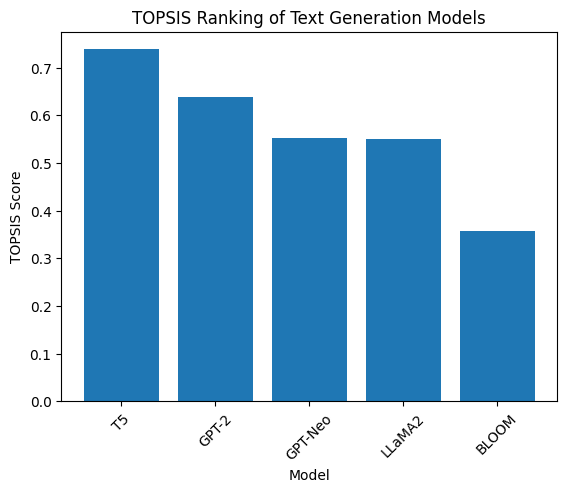

In [12]:
plt.figure()
plt.bar(data['Model'], data['TOPSIS Score'])
plt.title("TOPSIS Ranking of Text Generation Models")
plt.xlabel("Model")
plt.ylabel("TOPSIS Score")
plt.xticks(rotation=45)
plt.show()